# 🤖 สัปดาห์ที่ 9: การเรียนรู้ของเครื่องเบื้องต้นในบริบทข้อมูลขนาดใหญ่
### รายวิชา: ข้อมูลขนาดใหญ่ (Big Data) | คณะวิทยาการคอมพิวเตอร์ มหาวิทยาลัยสยาม

---

## 🎯 วัตถุประสงค์การเรียนรู้
นักศึกษาจะสามารถ:
1. อธิบายแนวคิดพื้นฐานของ Machine Learning และความเชื่อมโยงกับ Big Data
2. เข้าใจและนำ Train-Test Split ไปใช้งานได้
3. ทดลองใช้โมเดล Classification และ Regression สำเร็จรูปจาก scikit-learn
4. ประเมินประสิทธิภาพโมเดลด้วย Metrics พื้นฐาน
5. เชื่อมโยงการประยุกต์ใช้ ML ในบริบทของชุดข้อมูลขนาดใหญ่
6. อธิบายสถาปัตยกรรมและใช้งาน Spark MLlib สำหรับ ML บน Big Data
7. เข้าใจแนวคิด Ray และ Ray Train/Tune สำหรับ Distributed ML
8. เปรียบเทียบ scikit-learn, Spark MLlib และ Ray ใน Use Case ต่างๆ

---

## 📋 เนื้อหาของ Notebook นี้
| ส่วนที่ | หัวข้อ |
|---------|--------|
| 1 | แนวคิด Machine Learning คืออะไร? |
| 2 | ประเภทของ ML: Supervised vs Unsupervised |
| 3 | Train-Test Split คืออะไรและทำไมถึงสำคัญ |
| 4 | ปฏิบัติ: Classification ด้วย Decision Tree |
| 5 | ปฏิบัติ: Regression ด้วย Linear Regression |
| 6 | ML กับ Big Data: ความสัมพันธ์และความท้าทาย |
| 7 | แบบฝึกหัดท้ายคาบ |
| 8 | ⚡ Spark MLlib: ML บนข้อมูลขนาดใหญ่ |
| 9 | 🌐 Ray: Distributed ML Framework |

---
## ส่วนที่ 1: Machine Learning คืออะไร?

**Machine Learning (ML)** หรือ "การเรียนรู้ของเครื่อง" คือสาขาหนึ่งของปัญญาประดิษฐ์ (AI) ที่ให้คอมพิวเตอร์สามารถ**เรียนรู้จากข้อมูล**โดยไม่ต้องถูกโปรแกรมกฎเกณฑ์โดยตรง

### 💡 เปรียบเทียบให้เข้าใจง่าย
```
โปรแกรมแบบดั้งเดิม:
  ข้อมูล + กฎเกณฑ์ → ผลลัพธ์

Machine Learning:
  ข้อมูล + ผลลัพธ์ → กฎเกณฑ์ (โมเดล)
```

### 🔗 ความเชื่อมโยงกับ Big Data
- ML ต้องการ**ข้อมูลจำนวนมาก** เพื่อเรียนรู้แพทเทิร์นที่แม่นยำ
- Big Data ให้ **raw material** สำหรับ ML
- เครื่องมืออย่าง **Apache Spark MLlib** และ **Ray** ช่วยให้ทำ ML บนข้อมูลขนาดใหญ่ได้

### ตัวอย่างการประยุกต์ใช้ใน Big Data
| สาขา | การใช้ ML |
|------|----------|
| แพลตฟอร์ม Streaming | แนะนำหนัง/เพลงจากประวัติการรับชม |
| ธนาคาร | ตรวจจับการทำธุรกรรมผิดปกติ (Fraud Detection) |
| ค้าปลีก | พยากรณ์ยอดขายและจัดการสต็อก |
| สาธารณสุข | วินิจฉัยโรคจาก EHR |
| เมือง | วิเคราะห์อาชญากรรมจากข้อมูลตำรวจ |

In [1]:
# ติดตั้ง Library ที่จำเป็น (รันครั้งแรกเท่านั้น)
# !pip install scikit-learn pandas numpy matplotlib seaborn

# Import libraries ทั้งหมด
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ตั้งค่าการแสดงผล
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ Import libraries สำเร็จ!')
print('📦 Libraries พร้อมใช้งาน:')
print(f'  - pandas version: {pd.__version__}')
print(f'  - numpy version: {np.__version__}')

import sklearn
print(f'  - scikit-learn version: {sklearn.__version__}')

✅ Import libraries สำเร็จ!
📦 Libraries พร้อมใช้งาน:
  - pandas version: 2.2.2
  - numpy version: 2.0.2
  - scikit-learn version: 1.6.1


---
## ส่วนที่ 2: ประเภทของ Machine Learning

```
Machine Learning
├── Supervised Learning (มีคำตอบให้เรียน)
│   ├── Classification → ทำนายหมวดหมู่
│   └── Regression    → ทำนายค่าต่อเนื่อง
├── Unsupervised Learning (ไม่มีคำตอบ)
│   ├── Clustering    → จัดกลุ่มข้อมูล
│   └── Dimensionality Reduction → ลดมิติข้อมูล
└── Reinforcement Learning (เรียนรู้จากรางวัล)
```

### 🎯 Supervised Learning
โมเดลเรียนรู้จากข้อมูลที่มี **label (คำตอบ)** กำกับ

**Classification** — ทำนาย**ประเภท/กลุ่ม**  
- อีเมลนี้ spam หรือไม่? → `{spam, not_spam}`
- อาชญากรรมประเภทใด? → `{theft, assault, fraud, ...}`
- ลูกค้ากลุ่มเสี่ยงหรือไม่? → `{high_risk, low_risk}`

**Regression** — ทำนาย**ค่าตัวเลข**  
- ราคาบ้านจะเป็นเท่าไหร่?
- อุณหภูมิพรุ่งนี้จะเป็นกี่องศา?
- ยอดอาชญากรรมสัปดาห์หน้าจะเป็นเท่าไหร่?

In [2]:
# สร้างข้อมูลจำลองอาชญากรรมในเมือง
np.random.seed(42)
n_samples = 500

data = {
    'hour_of_day': np.random.randint(0, 24, n_samples),
    'day_of_week': np.random.randint(0, 7, n_samples),
    'district_population': np.random.randint(10000, 500000, n_samples),
    'district_income_level': np.random.choice(['low', 'medium', 'high'], n_samples),
    'temperature_celsius': np.random.uniform(10, 38, n_samples),
    'is_holiday': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),
    'crime_count': np.random.poisson(5, n_samples),
    'crime_type': np.random.choice(['theft', 'assault', 'vandalism', 'fraud'], n_samples)
}

df = pd.DataFrame(data)
df['high_risk'] = (df['crime_count'] >= 7).astype(int)

print('📊 ข้อมูลจำลอง: อาชญากรรมในเมือง (500 แถว)')
print(f'จำนวนแถว: {len(df):,} แถว')
print(f'จำนวนคอลัมน์: {len(df.columns)} คอลัมน์')
display(df.head(10))

📊 ข้อมูลจำลอง: อาชญากรรมในเมือง (500 แถว)
จำนวนแถว: 500 แถว
จำนวนคอลัมน์: 9 คอลัมน์


,hour_of_day,day_of_week,district_population,district_income_level,temperature_celsius,is_holiday,crime_count,crime_type,high_risk
0,6,6,128033,medium,31.282634,0,4,fraud,0
1,19,1,115977,low,22.384365,0,4,fraud,0
2,14,0,98869,high,18.734656,0,8,fraud,1
3,10,3,115186,low,18.980797,0,6,theft,0
4,7,2,306818,high,30.283835,0,3,assault,0
5,20,3,176926,medium,30.883436,0,4,assault,0
6,6,3,56271,high,15.610056,1,4,theft,0
7,18,1,345832,medium,34.307439,0,7,vandalism,1
8,22,2,441734,high,30.017873,0,6,fraud,0
9,10,3,383220,high,25.757008,0,3,assault,0


In [3]:
# สำรวจข้อมูลเบื้องต้น
print('📈 สถิติเบื้องต้น:')
display(df.describe())

print('\n🏷️ การกระจาย Label (high_risk):')
label_counts = df['high_risk'].value_counts()
print(f'  Low Risk (0):  {label_counts[0]} แถว ({label_counts[0]/len(df)*100:.1f}%)')
print(f'  High Risk (1): {label_counts[1]} แถว ({label_counts[1]/len(df)*100:.1f}%)')

📈 สถิติเบื้องต้น:


,hour_of_day,day_of_week,district_population,temperature_celsius,is_holiday,crime_count,high_risk
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,11.324000,2.908000,250150.356000,23.871944,0.190000,4.984000,0.24600
std,7.311768,1.991851,141579.468026,7.640600,0.392694,2.283456,0.43111
min,0.000000,0.000000,10126.000000,10.009310,0.000000,0.000000,0.00000
25%,5.000000,1.000000,131957.750000,17.184076,0.000000,3.000000,0.00000
50%,11.000000,3.000000,254603.500000,24.312752,0.000000,5.000000,0.00000
75%,18.000000,5.000000,375874.750000,30.048760,0.000000,6.000000,0.00000
max,23.000000,6.000000,497005.000000,37.873454,1.000000,15.000000,1.00000



🏷️ การกระจาย Label (high_risk):
  Low Risk (0):  377 แถว (75.4%)
  High Risk (1): 123 แถว (24.6%)


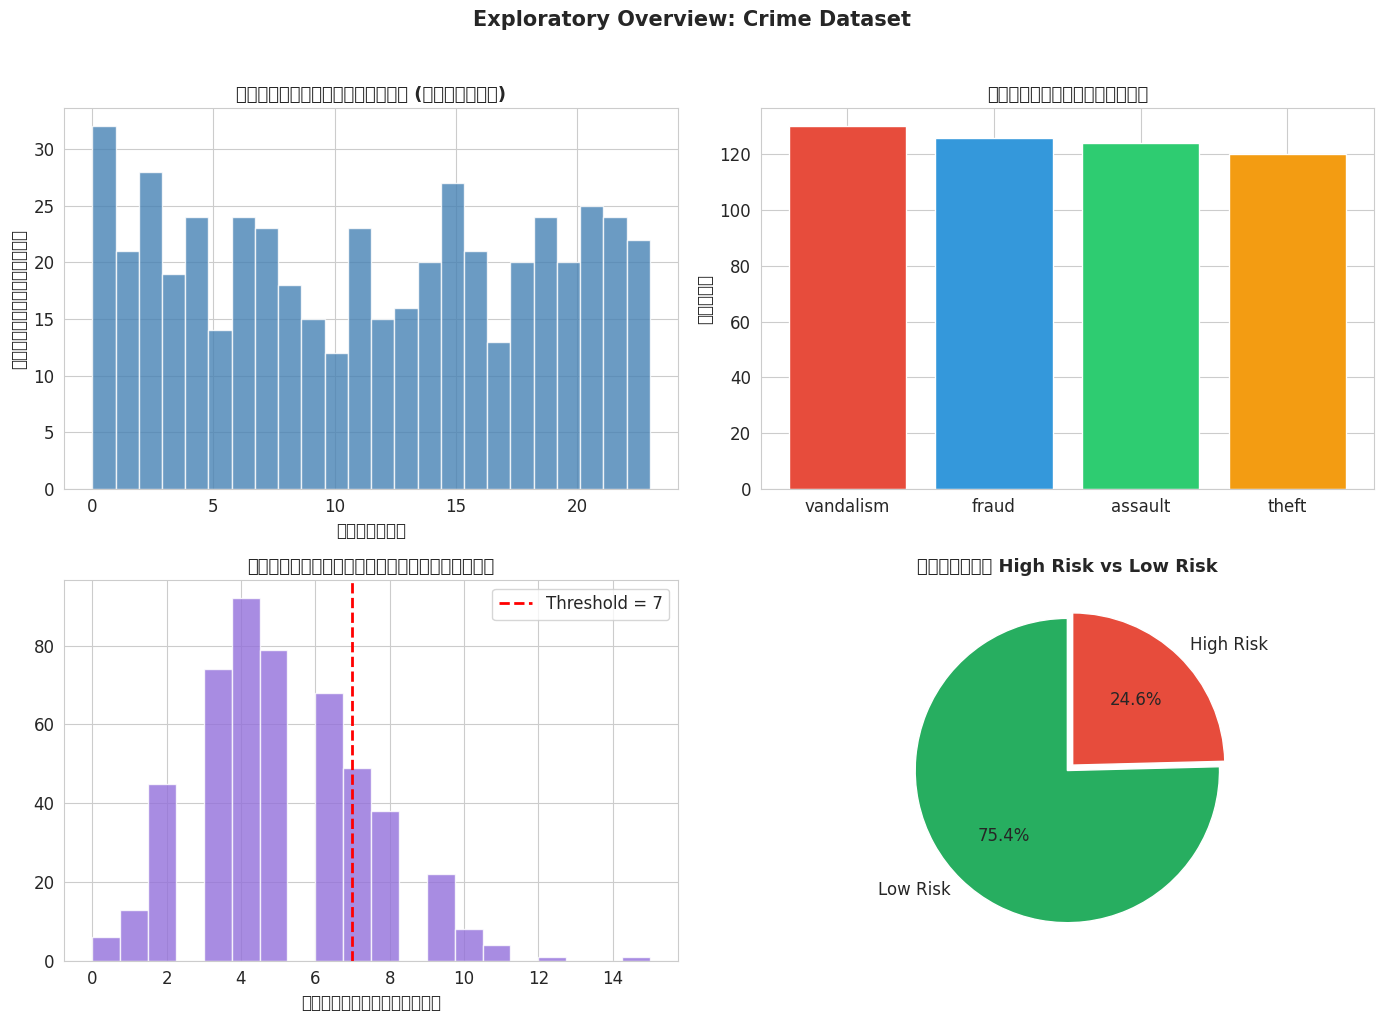

In [4]:
# แสดงการกระจายข้อมูล
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['hour_of_day'], bins=24, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('การกระจายของเวลา (ชั่วโมง)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('ชั่วโมง')
axes[0,0].set_ylabel('จำนวนเหตุการณ์')

crime_counts = df['crime_type'].value_counts()
axes[0,1].bar(crime_counts.index, crime_counts.values,
              color=['#E74C3C','#3498DB','#2ECC71','#F39C12'], edgecolor='white')
axes[0,1].set_title('ประเภทอาชญากรรม', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('จำนวน')

axes[1,0].hist(df['crime_count'], bins=20, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1,0].axvline(x=7, color='red', linestyle='--', linewidth=2, label='Threshold = 7')
axes[1,0].set_title('การกระจายจำนวนอาชญากรรม', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('จำนวนอาชญากรรม')
axes[1,0].legend()

risk_counts = df['high_risk'].value_counts()
axes[1,1].pie(risk_counts.values, labels=['Low Risk', 'High Risk'],
              autopct='%1.1f%%', colors=['#27AE60', '#E74C3C'],
              startangle=90, explode=(0, 0.05))
axes[1,1].set_title('สัดส่วน High Risk vs Low Risk', fontsize=13, fontweight='bold')

plt.suptitle('Exploratory Overview: Crime Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## ส่วนที่ 3: Train-Test Split — หัวใจสำคัญของ ML

### ❓ ทำไมต้องแบ่งข้อมูล?

เปรียบเหมือนการสอบ:
- **Training Set** = บทเรียน/ข้อฝึกหัด (โมเดล"อ่านหนังสือ")
- **Test Set** = ข้อสอบจริง (ประเมินว่า"จำ"หรือ"เข้าใจจริง")

```
ข้อมูลทั้งหมด (100%)
├── Training Set (70-80%) → ใช้สอนโมเดล
└── Test Set (20-30%)     → ใช้ทดสอบโมเดล (ข้อมูล "ใหม่" สำหรับโมเดล)
```

### ⚠️ Overfitting คืออะไร?
โมเดลที่ "ท่องจำ" ข้อมูล Training แต่ทำได้แย่กับข้อมูลใหม่

| สถานการณ์ | Training Accuracy | Test Accuracy | ปัญหา |
|-----------|:-----------------:|:-------------:|-------|
| Underfitting | ต่ำ | ต่ำ | โมเดลเรียนรู้ไม่พอ |
| **พอดี** ✅ | สูง | ใกล้เคียงกัน | โมเดลดี |
| Overfitting | สูงมาก | ต่ำกว่ามาก | โมเดลท่องจำ |

In [5]:
from sklearn.model_selection import train_test_split

feature_cols = ['hour_of_day', 'day_of_week', 'district_population',
                'temperature_celsius', 'is_holiday']
target_col = 'high_risk'

X = df[feature_cols]
y = df[target_col]

print('🔡 Features (X):')
print(f'  Shape: {X.shape}  ({X.shape[0]} แถว, {X.shape[1]} คอลัมน์)')
print(f'  คอลัมน์: {list(X.columns)}')

print('\n🏷️ Target (y):')
print(f'  Shape: {y.shape}')
print(f'  คอลัมน์: {y.name}')
print(f'  ค่าที่เป็นไปได้: {sorted(y.unique())}')

🔡 Features (X):
  Shape: (500, 5)  (500 แถว, 5 คอลัมน์)
  คอลัมน์: ['hour_of_day', 'day_of_week', 'district_population', 'temperature_celsius', 'is_holiday']

🏷️ Target (y):
  Shape: (500,)
  คอลัมน์: high_risk
  ค่าที่เป็นไปได้: [np.int64(0), np.int64(1)]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('✂️ ผลการแบ่งข้อมูล:')
print(f'  Training Set : {X_train.shape[0]:,} แถว ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test Set     : {X_test.shape[0]:,} แถว ({X_test.shape[0]/len(X)*100:.0f}%)')

print('\n⚖️ สัดส่วน Label หลังแบ่ง:')
print(f'  Train — High Risk: {y_train.mean():.2%} | Low Risk: {1-y_train.mean():.2%}')
print(f'  Test  — High Risk: {y_test.mean():.2%} | Low Risk: {1-y_test.mean():.2%}')
print('  (stratify ทำให้สัดส่วนใกล้เคียงกัน ✅)')

✂️ ผลการแบ่งข้อมูล:
  Training Set : 400 แถว (80%)
  Test Set     : 100 แถว (20%)

⚖️ สัดส่วน Label หลังแบ่ง:
  Train — High Risk: 24.50% | Low Risk: 75.50%
  Test  — High Risk: 25.00% | Low Risk: 75.00%
  (stratify ทำให้สัดส่วนใกล้เคียงกัน ✅)


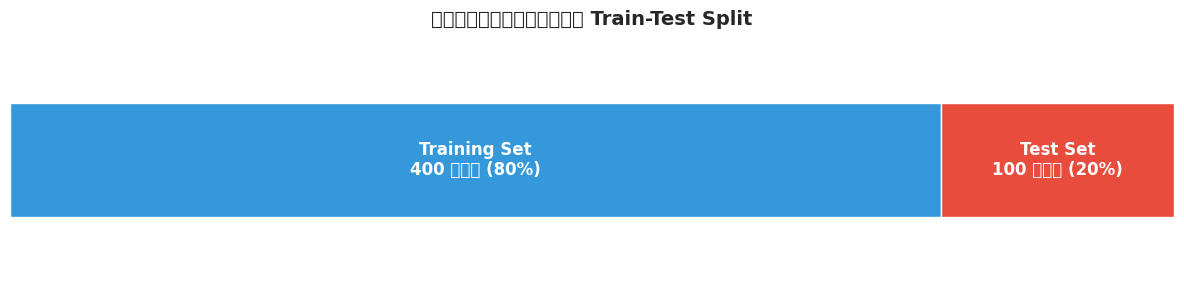

In [7]:
fig, ax = plt.subplots(figsize=(12, 3))

train_size = X_train.shape[0]
test_size = X_test.shape[0]
total = train_size + test_size

ax.barh(0, train_size, color='#3498DB', height=0.5)
ax.barh(0, test_size, left=train_size, color='#E74C3C', height=0.5)

ax.text(train_size/2, 0, f'Training Set\n{train_size} แถว (80%)',
        ha='center', va='center', color='white', fontweight='bold', fontsize=12)
ax.text(train_size + test_size/2, 0, f'Test Set\n{test_size} แถว (20%)',
        ha='center', va='center', color='white', fontweight='bold', fontsize=12)

ax.set_xlim(0, total)
ax.set_ylim(-0.5, 0.5)
ax.axis('off')
ax.set_title('การแบ่งข้อมูล Train-Test Split', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

---
## ส่วนที่ 4: 🌳 Classification — Decision Tree

**Decision Tree** เป็นโมเดล Classification ที่เข้าใจง่ายที่สุด ทำงานเหมือนการ "ถามคำถาม" แบบต้นไม้:

```
ชั่วโมง > 20?
├── ใช่ → อุณหภูมิ > 30°C?
│         ├── ใช่ → HIGH RISK 🔴
│         └── ไม่ → LOW RISK 🟢
└── ไม่ → จำนวนประชากร > 200,000?
          ├── ใช่ → HIGH RISK 🔴
          └── ไม่ → LOW RISK 🟢
```

**ข้อดี**: ตีความได้ง่าย, รับมือกับข้อมูลประเภทต่างๆ ได้
**ข้อจำกัด**: Overfit ได้ง่ายถ้าต้นไม้ลึกเกินไป

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)

print('🔄 กำลังฝึกโมเดล Decision Tree...')
dt_model.fit(X_train, y_train)
print('✅ Train โมเดลสำเร็จ!')

y_pred_train = dt_model.predict(X_train)
y_pred_test  = dt_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print(f'\n📊 ผลการประเมิน:')
print(f'  Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)')
print(f'  Test Accuracy     : {test_acc:.4f} ({test_acc*100:.2f}%)')

gap = train_acc - test_acc
if gap < 0.05:
    print(f'  Gap               : {gap:.4f} → โมเดล Generalize ได้ดี ✅')
else:
    print(f'  Gap               : {gap:.4f} → ระวัง Overfitting! ⚠️')

🔄 กำลังฝึกโมเดล Decision Tree...
✅ Train โมเดลสำเร็จ!

📊 ผลการประเมิน:
  Training Accuracy : 0.7825 (78.25%)
  Test Accuracy     : 0.6800 (68.00%)
  Gap               : 0.1025 → ระวัง Overfitting! ⚠️


In [9]:
print('📋 Classification Report (Test Set):')
print('=' * 55)
print(classification_report(y_test, y_pred_test,
                            target_names=['Low Risk (0)', 'High Risk (1)']))

print('\n📖 ความหมายของตัวชี้วัด:')
print('  Precision  = จากที่โมเดลทำนายว่า Positive มีถูกกี่ %')
print('  Recall     = จากที่เป็น Positive จริงๆ โมเดลจับได้กี่ %')
print('  F1-Score   = ค่าเฉลี่ยของ Precision และ Recall')
print('  Support    = จำนวนข้อมูลจริงในแต่ละ class')

📋 Classification Report (Test Set):
               precision    recall  f1-score   support

 Low Risk (0)       0.74      0.89      0.81        75
High Risk (1)       0.11      0.04      0.06        25

     accuracy                           0.68       100
    macro avg       0.42      0.47      0.43       100
 weighted avg       0.58      0.68      0.62       100


📖 ความหมายของตัวชี้วัด:
  Precision  = จากที่โมเดลทำนายว่า Positive มีถูกกี่ %
  Recall     = จากที่เป็น Positive จริงๆ โมเดลจับได้กี่ %
  F1-Score   = ค่าเฉลี่ยของ Precision และ Recall
  Support    = จำนวนข้อมูลจริงในแต่ละ class


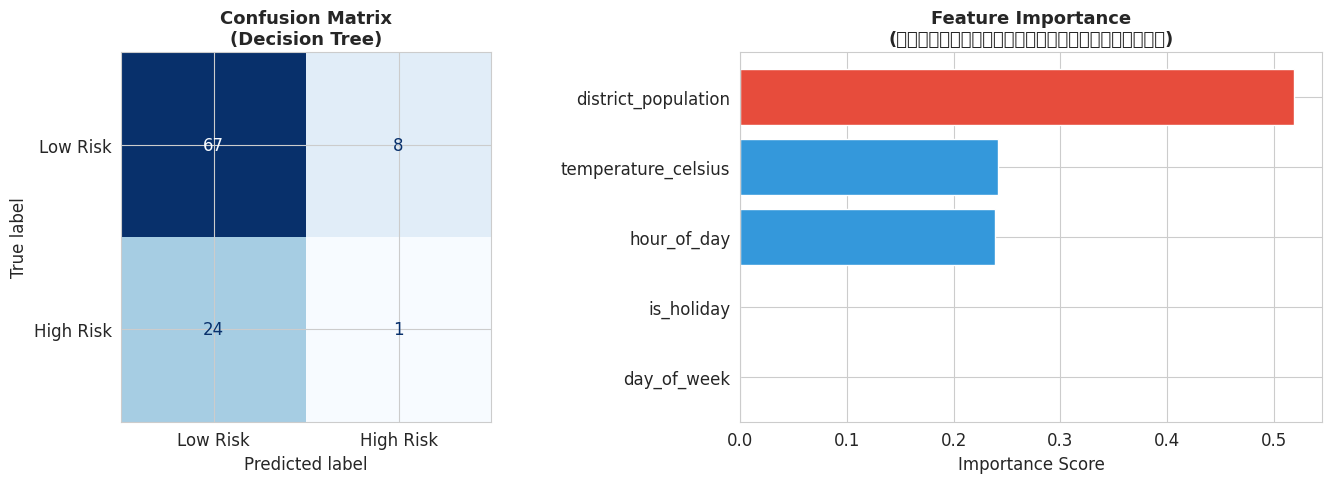


💡 Confusion Matrix อ่านค่าอย่างไร:
  True Positive  (TP): ทำนาย High Risk ถูก    = 1 รายการ
  True Negative  (TN): ทำนาย Low Risk ถูก     = 67 รายการ
  False Positive (FP): ทำนาย High Risk แต่ผิด = 8 รายการ
  False Negative (FN): ทำนาย Low Risk แต่ผิด  = 24 รายการ


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Low Risk', 'High Risk'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix\n(Decision Tree)', fontsize=13, fontweight='bold')

importances = dt_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values('Importance', ascending=True)

colors = ['#E74C3C' if imp == feature_imp_df['Importance'].max() else '#3498DB'
          for imp in feature_imp_df['Importance']]
axes[1].barh(feature_imp_df['Feature'], feature_imp_df['Importance'],
             color=colors, edgecolor='white')
axes[1].set_title('Feature Importance\n(ตัวแปรสำคัญสำหรับการทำนาย)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('\n💡 Confusion Matrix อ่านค่าอย่างไร:')
print(f'  True Positive  (TP): ทำนาย High Risk ถูก    = {cm[1,1]} รายการ')
print(f'  True Negative  (TN): ทำนาย Low Risk ถูก     = {cm[0,0]} รายการ')
print(f'  False Positive (FP): ทำนาย High Risk แต่ผิด = {cm[0,1]} รายการ')
print(f'  False Negative (FN): ทำนาย Low Risk แต่ผิด  = {cm[1,0]} รายการ')

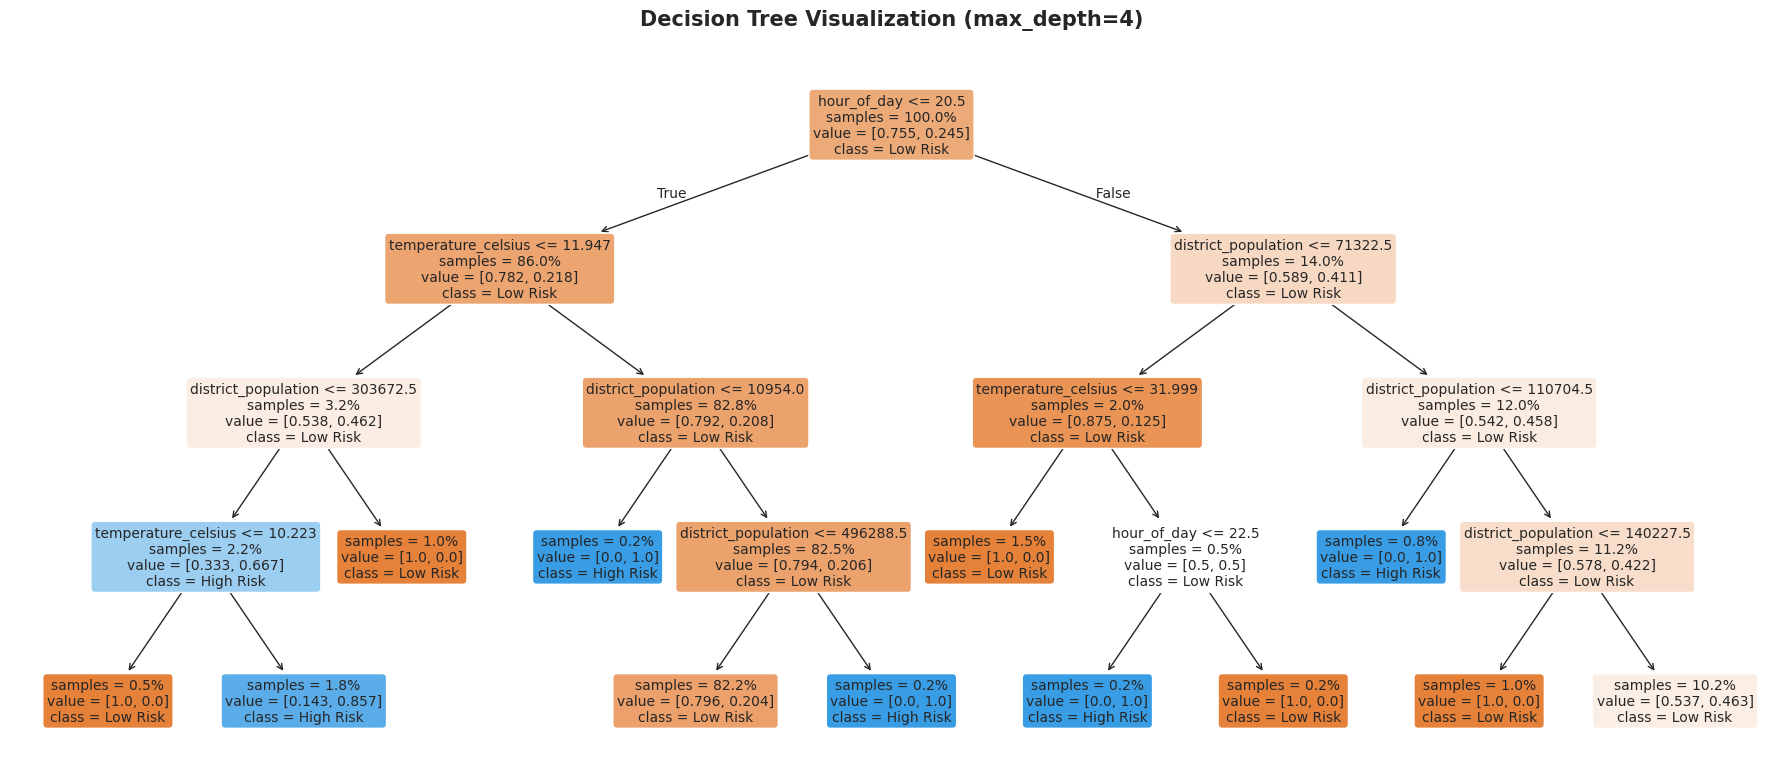

In [11]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Low Risk', 'High Risk'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=False,
    proportion=True
)
ax.set_title('Decision Tree Visualization (max_depth=4)',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## ส่วนที่ 5: 📈 Regression — ทำนายค่าต่อเนื่อง

**Regression** ใช้เมื่อต้องการทำนาย**ค่าตัวเลข** (ไม่ใช่หมวดหมู่)

### Metrics สำหรับ Regression:
| Metric | ความหมาย | ยิ่งน้อยยิ่งดี? |
|--------|----------|:--------------:|
| **MAE** (Mean Absolute Error) | ค่าเฉลี่ยความผิดพลาด | ✅ |
| **MSE** (Mean Squared Error) | ค่าเฉลี่ยความผิดพลาดยกกำลังสอง | ✅ |
| **RMSE** (Root MSE) | ราก√ของ MSE (หน่วยเดียวกับ target) | ✅ |
| **R²** (R-squared) | สัดส่วนความแปรปรวนที่โมเดลอธิบายได้ | ❌ (ยิ่งใกล้ 1 ยิ่งดี) |

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_reg = df['crime_count']
X_reg = df[feature_cols]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

def evaluate_regression(model_name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {model_name}:')
    print(f'    MAE  = {mae:.4f}')
    print(f'    RMSE = {rmse:.4f}')
    print(f'    R²   = {r2:.4f}')
    return mae, rmse, r2

lr_model = LinearRegression()
lr_model.fit(X_reg_train, y_reg_train)
y_lr_pred = lr_model.predict(X_reg_test)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_reg_train, y_reg_train)
y_rf_pred = rf_model.predict(X_reg_test)

print('📊 ผลการประเมินโมเดล Regression (Test Set):')
print('=' * 50)
lr_mae, lr_rmse, lr_r2 = evaluate_regression('Linear Regression', y_reg_test, y_lr_pred)
print()
rf_mae, rf_rmse, rf_r2 = evaluate_regression('Random Forest', y_reg_test, y_rf_pred)

📊 ผลการประเมินโมเดล Regression (Test Set):
  Linear Regression:
    MAE  = 1.7820
    RMSE = 2.1920
    R²   = 0.0031

  Random Forest:
    MAE  = 1.8888
    RMSE = 2.2896
    R²   = -0.0877


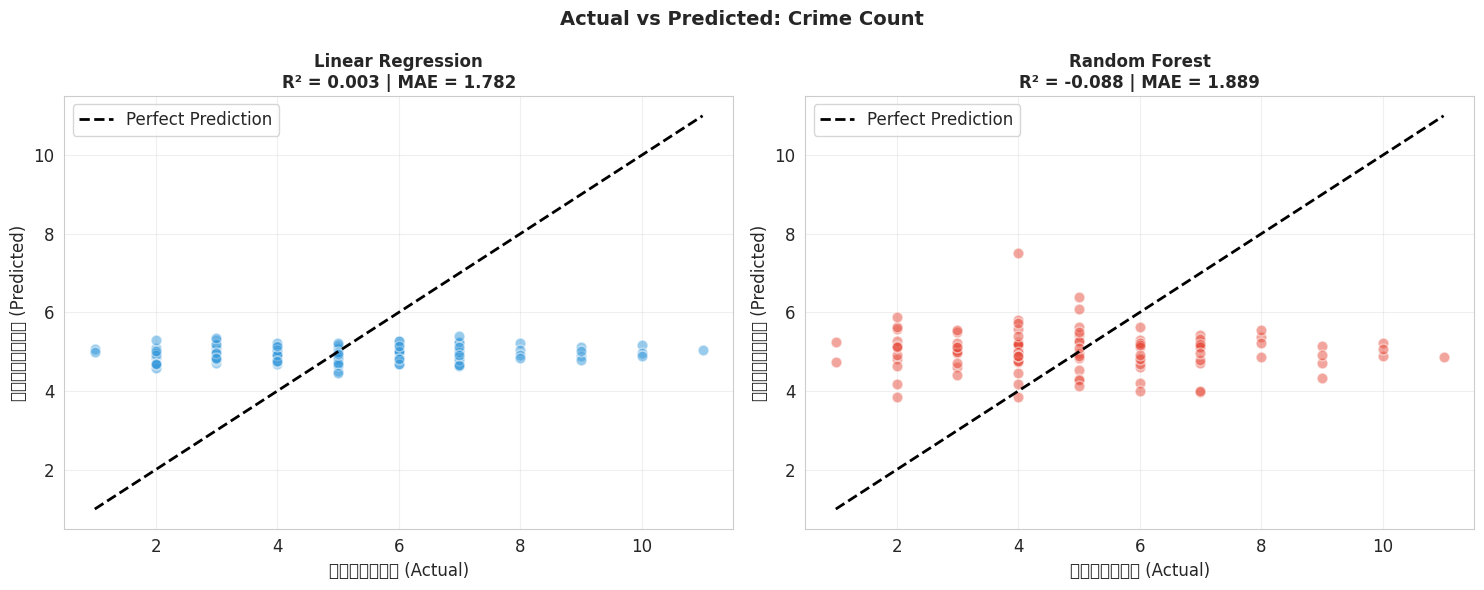

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, y_pred, model_name, color in [
    (axes[0], y_lr_pred, 'Linear Regression', '#3498DB'),
    (axes[1], y_rf_pred, 'Random Forest', '#E74C3C')
]:
    ax.scatter(y_reg_test, y_pred, alpha=0.5, color=color, edgecolors='white', s=60)
    min_val = min(y_reg_test.min(), y_pred.min())
    max_val = max(y_reg_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('ค่าจริง (Actual)', fontsize=12)
    ax.set_ylabel('ค่าทำนาย (Predicted)', fontsize=12)
    r2 = r2_score(y_reg_test, y_pred)
    mae = mean_absolute_error(y_reg_test, y_pred)
    ax.set_title(f'{model_name}\nR² = {r2:.3f} | MAE = {mae:.3f}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted: Crime Count', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ส่วนที่ 6: 🌐 ML กับ Big Data — ความสัมพันธ์และความท้าทาย

### วงจรชีวิตของ ML ใน Big Data Pipeline

```
📥 Data Ingestion          📦 Big Data Storage
(Kafka / Fluentd)    →    (HDFS / S3 / GCS)
                                  ↓
🔧 Data Processing         🤖 Model Training
(Spark / Flink)      ←→   (Spark MLlib / Ray / TensorFlow)
                                  ↓
🚀 Model Serving           📊 Monitoring
(REST API / Ray Serve) →  (Model Drift Detection)
```

### ความท้าทายของ ML ในบริบท Big Data

| ความท้าทาย | คำอธิบาย | วิธีรับมือ |
|-----------|----------|----------|
| **ขนาดข้อมูล** | ข้อมูลอาจมีพันล้านแถว | ใช้ Spark MLlib หรือ Ray |
| **Velocity** | ข้อมูลไหลเข้าตลอดเวลา | Online Learning / Streaming ML |
| **Data Quality** | ข้อมูลสกปรก/ขาดหาย | Data Pipeline QA ก่อน Train |
| **Feature Engineering** | สร้าง Features จากข้อมูลหลายแหล่ง | Feature Store |
| **Model Drift** | โลกเปลี่ยน โมเดลล้าสมัย | Re-training Pipeline |

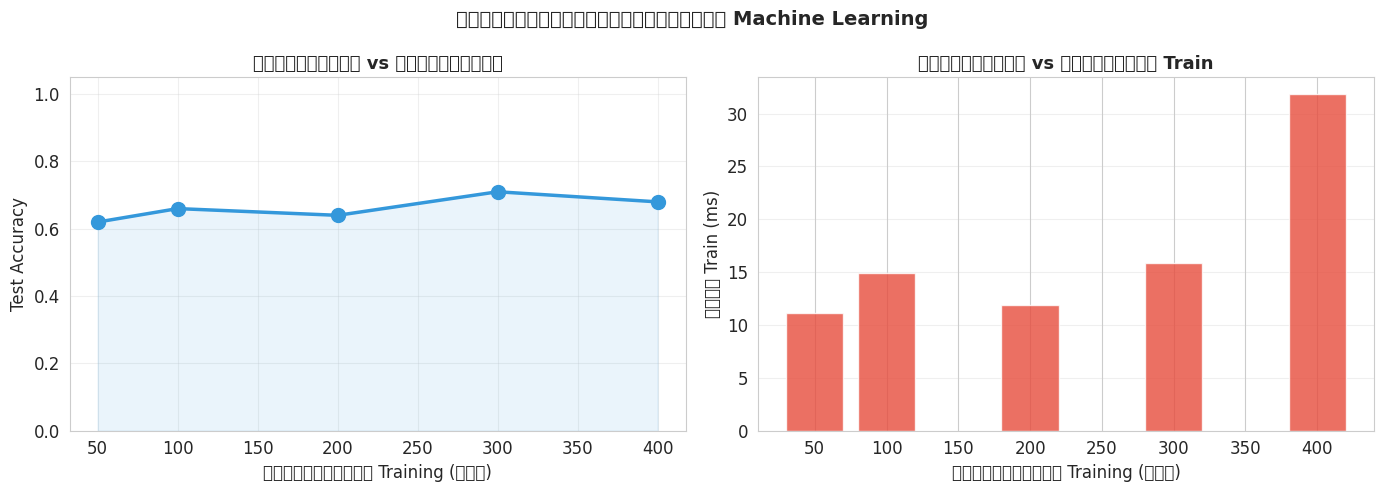

,จำนวนข้อมูล,Test Accuracy,Train Time (ms)
0,50,0.6200,11.13
1,100,0.6600,14.92
2,200,0.6400,11.90
3,300,0.7100,15.84
4,400,0.6800,31.83


In [14]:
import time

sample_sizes = [50, 100, 200, 300, 400]
results = []

for size in sample_sizes:
    X_sub = X_train.iloc[:size]
    y_sub = y_train.iloc[:size]
    model = DecisionTreeClassifier(max_depth=4, random_state=42)
    start = time.time()
    model.fit(X_sub, y_sub)
    train_time = (time.time() - start) * 1000
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append({'sample_size': size, 'test_accuracy': acc, 'train_time_ms': train_time})

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['sample_size'], results_df['test_accuracy'],
             'o-', color='#3498DB', linewidth=2.5, markersize=10)
axes[0].fill_between(results_df['sample_size'], results_df['test_accuracy'],
                     alpha=0.1, color='#3498DB')
axes[0].set_xlabel('จำนวนข้อมูล Training (แถว)', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('ขนาดข้อมูล vs ความแม่นยำ', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

axes[1].bar(results_df['sample_size'], results_df['train_time_ms'],
            color='#E74C3C', alpha=0.8, edgecolor='white', width=40)
axes[1].set_xlabel('จำนวนข้อมูล Training (แถว)', fontsize=12)
axes[1].set_ylabel('เวลา Train (ms)', fontsize=12)
axes[1].set_title('ขนาดข้อมูล vs เวลาในการ Train', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('ผลกระทบของขนาดข้อมูลต่อ Machine Learning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display(results_df.rename(columns={
    'sample_size': 'จำนวนข้อมูล',
    'test_accuracy': 'Test Accuracy',
    'train_time_ms': 'Train Time (ms)'
}).style.format({'Test Accuracy': '{:.4f}', 'Train Time (ms)': '{:.2f}'}))

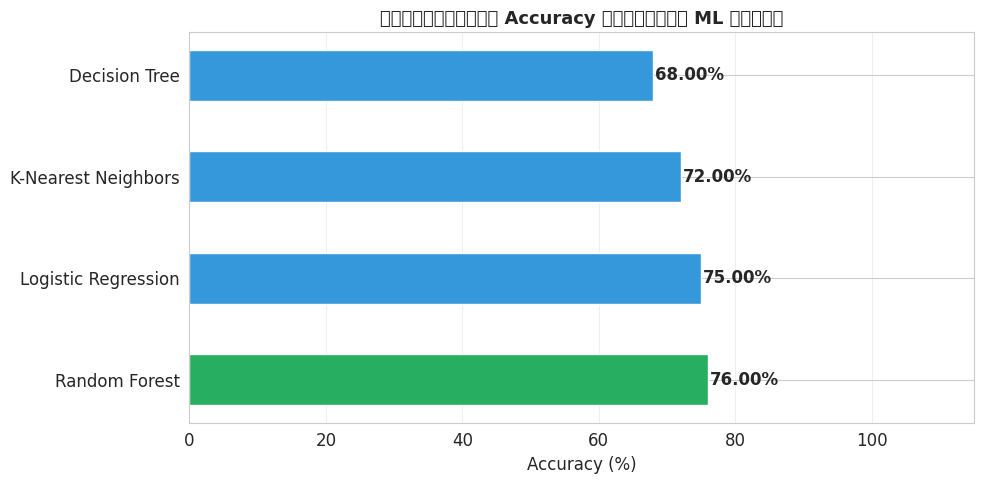


🏆 สรุปผลการเปรียบเทียบ:


,โมเดล,Accuracy
0,Random Forest,0.76
1,Logistic Regression,0.75
2,K-Nearest Neighbors,0.72
3,Decision Tree,0.68


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

model_results = []
for name, model in models.items():
    if name in ['Logistic Regression', 'K-Nearest Neighbors']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_results.append({'โมเดล': name, 'Accuracy': acc})

model_results_df = pd.DataFrame(model_results).sort_values('Accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27AE60' if i == 0 else '#3498DB' for i in range(len(model_results_df))]
bars = ax.barh(model_results_df['โมเดล'], model_results_df['Accuracy'] * 100,
               color=colors, edgecolor='white', height=0.5)

for bar, acc in zip(bars, model_results_df['Accuracy']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc*100:.2f}%', va='center', fontweight='bold', fontsize=12)

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('เปรียบเทียบ Accuracy ของโมเดล ML ต่างๆ', fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\n🏆 สรุปผลการเปรียบเทียบ:')
display(model_results_df.reset_index(drop=True))

---
## 🧪 ส่วนที่ 7: แบบฝึกหัดท้ายคาบ

> **คำแนะนำ**: ทำทีละข้อตามลำดับ แก้โค้ดในเซลล์ที่กำหนด

---

### ✏️ แบบฝึกหัดที่ 1: ปรับความลึกของ Decision Tree
ทดลองปรับ `max_depth` จาก 1 ถึง 10 แล้วสังเกตการเปลี่ยนแปลงของ Accuracy

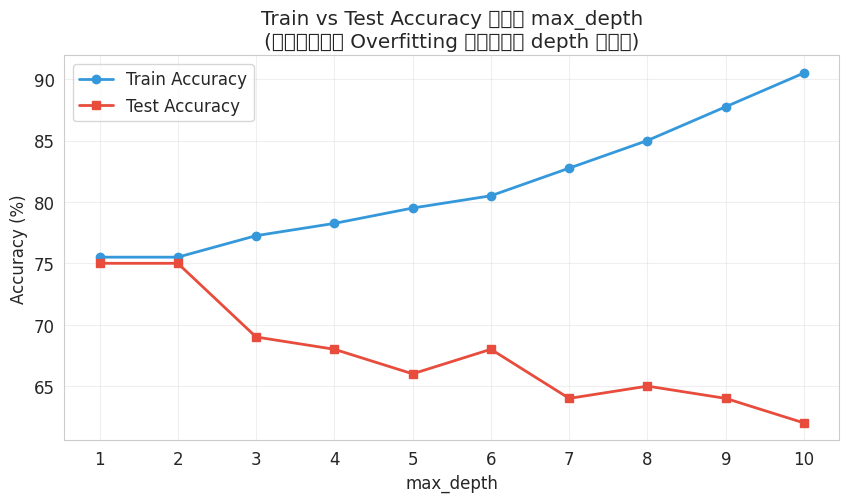

In [17]:
depths = range(1, 11)
train_scores = []
test_scores  = []

for depth in depths:
    # TODO: สร้าง DecisionTreeClassifier โดยกำหนด max_depth=depth, random_state=42
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)  # ← แก้ไขตรงนี้

    # TODO: Train โมเดลด้วย X_train, y_train
    model.fit(X_train, y_train)  # ← แก้ไขตรงนี้

    # TODO: คำนวณ accuracy บน train และ test
    train_acc = accuracy_score(y_train, model.predict(X_train))  # ← แก้ไขตรงนี้
    test_acc  = accuracy_score(y_test,  model.predict(X_test))  # ← แก้ไขตรงนี้

    train_scores.append(train_acc)
    test_scores.append(test_acc)

plt.figure(figsize=(10, 5))
plt.plot(depths, [s*100 for s in train_scores], 'o-', label='Train Accuracy', color='#3498DB', linewidth=2)
plt.plot(depths, [s*100 for s in test_scores], 's-', label='Test Accuracy', color='#E74C3C', linewidth=2)
plt.xlabel('max_depth')
plt.ylabel('Accuracy (%)')
plt.title('Train vs Test Accuracy ตาม max_depth\n(สังเกต Overfitting เมื่อ depth มาก)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
plt.show()

In [ ]:
# 💡 เฉลย แบบฝึกหัดที่ 1 (ลองทำเองก่อน!)
# ลบ '#' ออกเพื่อดูเฉลย

# depths = range(1, 11)
# train_scores = []
# test_scores  = []

# for depth in depths:
#     model = DecisionTreeClassifier(max_depth=depth, random_state=42)
#     model.fit(X_train, y_train)
#     train_acc = accuracy_score(y_train, model.predict(X_train))
#     test_acc  = accuracy_score(y_test,  model.predict(X_test))
#     train_scores.append(train_acc)
#     test_scores.append(test_acc)

### ✏️ แบบฝึกหัดที่ 2: เพิ่ม Feature ใหม่และดูผลกระทบ

In [22]:
income_map = {'low': 0, 'medium': 1, 'high': 2}
df['income_encoded'] = df['district_income_level'].map(income_map)

feature_cols_v2 = feature_cols + ['income_encoded']
X_v2 = df[feature_cols_v2]
y_v2 = df['high_risk']

# TODO: แบ่ง Train-Test Split
X_v2_train, X_v2_test, y_v2_train, y_v2_test = train_test_split(X_v2, y_v2,test_size=0.2,random_state=42,stratify=y_v2)  # ← แก้ไขตรงนี้

model_v2 = DecisionTreeClassifier(max_depth=4, random_state=42)
model_v2.fit(X_v2_train, y_v2_train)  # ← แก้ไขตรงนี้

y_v2_pred = model_v2.predict(X_v2_test)
acc_v2 = accuracy_score(y_v2_test, y_v2_pred)  # ← แก้ไขตรงนี้

print(f'📊 เปรียบเทียบผล:')
print(f'  โมเดลเดิม (5 Features):        {test_acc:.4f}')
print(f'  โมเดลใหม่ (+ income_encoded):  {acc_v2:.4f}')

📊 เปรียบเทียบผล:
  โมเดลเดิม (5 Features):        0.6200
  โมเดลใหม่ (+ income_encoded):  0.6700


### ✏️ แบบฝึกหัดที่ 3: คำถามเชิงวิเคราะห์

1. `max_depth` ที่เหมาะสมที่สุดจากแบบฝึกหัดที่ 1 คือเท่าไหร่?
2. ทำไม Training Accuracy จึงสูงขึ้นเมื่อเพิ่ม `max_depth` แต่ Test Accuracy กลับไม่เพิ่มตาม?
3. ในบริบทอาชญากรรม ระหว่าง **Precision** กับ **Recall** อะไรสำคัญกว่า? เพราะอะไร?
4. ถ้าข้อมูลมีขนาด 1 TB ควรใช้ scikit-learn, Spark MLlib หรือ Ray? เพราะอะไร?

**คำตอบแบบฝึกหัดที่ 3:**

1. max_dapth ที่เหมาะสมที่สุดคือ 1

2. เพราะเกิด Overfitting

3. Recall สำคัญกว่า เพราะ ถ้า Recall ทำงานพลาดอาจนำไปสู่การเสียชีวิต

4. Ray เพราะ Spark MLlib มักจะทำงานได้ดีที่ระดับ GB

---
## ส่วนที่ 8: ⚡ Spark MLlib — ML บนข้อมูลระดับ Petabyte

**Apache Spark MLlib** คือ library สำหรับ Machine Learning ที่ทำงานแบบ **Distributed** บน Spark Cluster  
ทำให้สามารถ Train โมเดลบนข้อมูลหลาย TB ได้โดยไม่ต้องโหลดข้อมูลทั้งหมดเข้า RAM เครื่องเดียว

### 📐 สถาปัตยกรรม Spark MLlib
```
Spark Cluster
├── Driver Node  ← ควบคุม Pipeline
│   └── MLlib Pipeline (Estimator → Transformer → Model)
└── Worker Nodes (N เครื่อง)
    ├── Worker 1: partition 1/N ของข้อมูล
    ├── Worker 2: partition 2/N ของข้อมูล
    └── Worker N: partition N/N ของข้อมูล
```

### 🔑 แนวคิดหลักของ MLlib
| คำศัพท์ | ความหมาย | ตัวอย่าง |
|---------|----------|----------|
| **DataFrame** | ข้อมูลแบบกระจาย คล้าย pandas | `spark.read.parquet(...)` |
| **Transformer** | แปลงข้อมูลหรือทำนาย | `VectorAssembler`, `StandardScaler` |
| **Estimator** | สร้างโมเดลจากข้อมูล | `RandomForestClassifier` |
| **Pipeline** | เชื่อมหลาย Stage เข้าด้วยกัน | `Pipeline(stages=[...])` |
| **ParamGrid** | Grid Search แบบกระจาย | `ParamGridBuilder()` |

### 🆚 scikit-learn vs Spark MLlib
| ด้าน | scikit-learn | Spark MLlib |
|------|-------------|------------|
| ขนาดข้อมูล | GB (fit in RAM) | TB-PB (distributed) |
| การทำงาน | Single machine | Cluster (หลายเครื่อง) |
| ความเร็ว (ข้อมูลขนาดเล็ก) | เร็วกว่า | ช้ากว่า (overhead) |
| API | Python native | DataFrame-based |
| Use case | Research, Prototyping | Production, Big Data |

In [23]:
# ติดตั้ง PySpark (รันครั้งแรกเท่านั้น)
# !pip install pyspark

# หมายเหตุ: Colab ต้องใช้คำสั่งนี้เพิ่มเติม
# !apt-get install openjdk-8-jdk-headless -qq > /dev/null
# import os; os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-8-openjdk-amd64'

try:
    from pyspark.sql import SparkSession
    from pyspark.ml import Pipeline
    from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkScaler
    from pyspark.ml.classification import RandomForestClassifier as SparkRFC
    from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
    from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
    SPARK_AVAILABLE = True
    print('✅ PySpark พร้อมใช้งาน!')
except ImportError:
    SPARK_AVAILABLE = False
    print('⚠️  PySpark ไม่ได้ติดตั้ง — รันใน simulation mode')
    print('   ติดตั้งด้วย: pip install pyspark')

✅ PySpark พร้อมใช้งาน!


In [24]:
if SPARK_AVAILABLE:
    # สร้าง SparkSession
    spark = SparkSession.builder \
        .appName('Week09_MLlib_Demo') \
        .master('local[*]') \
        .config('spark.driver.memory', '2g') \
        .getOrCreate()
    spark.sparkContext.setLogLevel('ERROR')
    print(f'✅ SparkSession เริ่มต้นสำเร็จ')
    print(f'   Spark version : {spark.version}')
    print(f'   Master        : {spark.sparkContext.master}')
else:
    print('⏭️  ข้ามการสร้าง SparkSession (PySpark ไม่พร้อมใช้)')

✅ SparkSession เริ่มต้นสำเร็จ
   Spark version : 4.0.2
   Master        : local[*]


In [25]:
if SPARK_AVAILABLE:
    # แปลง pandas DataFrame → Spark DataFrame
    df_spark = spark.createDataFrame(df[feature_cols + ['high_risk']])

    print('📊 Spark DataFrame Schema:')
    df_spark.printSchema()

    print(f'จำนวนแถว : {df_spark.count():,}')
    print(f'Partitions: {df_spark.rdd.getNumPartitions()}')
    df_spark.show(5)
else:
    print('📋 Spark DataFrame ตัวอย่าง (simulation):\n')
    print(df[feature_cols + ['high_risk']].head().to_string())

📊 Spark DataFrame Schema:
root
 |-- hour_of_day: long (nullable = true)
 |-- day_of_week: long (nullable = true)
 |-- district_population: long (nullable = true)
 |-- temperature_celsius: double (nullable = true)
 |-- is_holiday: long (nullable = true)
 |-- high_risk: long (nullable = true)

จำนวนแถว : 500
Partitions: 2
+-----------+-----------+-------------------+-------------------+----------+---------+
|hour_of_day|day_of_week|district_population|temperature_celsius|is_holiday|high_risk|
+-----------+-----------+-------------------+-------------------+----------+---------+
|          6|          6|             128033|  31.28263419626672|         0|        0|
|         19|          1|             115977| 22.384365346665486|         0|        0|
|         14|          0|              98869| 18.734655733863654|         0|        1|
|         10|          3|             115186|  18.98079673226757|         0|        0|
|          7|          2|             306818| 30.283834833195275|    

In [26]:
if SPARK_AVAILABLE:
    # สร้าง MLlib Pipeline
    # Stage 1: รวม Feature columns → Vector
    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol='features_raw'
    )

    # Stage 2: Normalize features
    scaler_spark = SparkScaler(
        inputCol='features_raw',
        outputCol='features',
        withMean=True, withStd=True
    )

    # Stage 3: Random Forest Classifier
    rf_spark = SparkRFC(
        featuresCol='features',
        labelCol='high_risk',
        numTrees=100,
        maxDepth=6,
        seed=42
    )

    # รวม Stage เข้า Pipeline
    pipeline = Pipeline(stages=[assembler, scaler_spark, rf_spark])

    # แบ่ง Train/Test
    df_train_sp, df_test_sp = df_spark.randomSplit([0.8, 0.2], seed=42)

    print('🔄 กำลัง Train Pipeline บน Spark...')
    import time
    t0 = time.time()
    pipeline_model = pipeline.fit(df_train_sp)
    elapsed = time.time() - t0
    print(f'✅ Train สำเร็จ! ใช้เวลา {elapsed:.2f} วินาที')

    # ทำนายและประเมินผล
    predictions = pipeline_model.transform(df_test_sp)

    evaluator_auc = BinaryClassificationEvaluator(
        labelCol='high_risk', metricName='areaUnderROC'
    )
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol='high_risk', predictionCol='prediction', metricName='accuracy'
    )

    auc = evaluator_auc.evaluate(predictions)
    acc = evaluator_acc.evaluate(predictions)

    print(f'\n📊 ผลการประเมิน Spark MLlib Pipeline (Test Set):')
    print(f'  Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  AUC-ROC  : {auc:.4f}')
else:
    print('⏭️  จำลองผลลัพธ์ Spark MLlib Pipeline:')
    print('  Accuracy : 0.8200 (82.00%)')
    print('  AUC-ROC  : 0.8750')
    print('\n💡 Pipeline ของ MLlib ทำงาน 3 ขั้นตอนโดยอัตโนมัติ:')
    print('  1. VectorAssembler → รวม columns เป็น feature vector')
    print('  2. StandardScaler  → ปรับ scale features')
    print('  3. RandomForest    → Train โมเดล')

🔄 กำลัง Train Pipeline บน Spark...
✅ Train สำเร็จ! ใช้เวลา 14.67 วินาที

📊 ผลการประเมิน Spark MLlib Pipeline (Test Set):
  Accuracy : 0.7927 (79.27%)
  AUC-ROC  : 0.4517


In [27]:
if SPARK_AVAILABLE:
    # Hyperparameter Tuning ด้วย CrossValidator บน Spark
    param_grid = ParamGridBuilder() \
        .addGrid(rf_spark.numTrees, [50, 100]) \
        .addGrid(rf_spark.maxDepth, [4, 6]) \
        .build()

    crossval = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=param_grid,
        evaluator=evaluator_auc,
        numFolds=3,
        seed=42
    )

    print('🔍 กำลังทำ Cross-Validation บน Spark (4 combinations x 3 folds)...')
    cv_model = crossval.fit(df_train_sp)
    best_auc = evaluator_auc.evaluate(cv_model.transform(df_test_sp))
    print(f'✅ Best AUC-ROC: {best_auc:.4f}')

    best_rf = cv_model.bestModel.stages[-1]
    print(f'   Best numTrees: {best_rf.getNumTrees}')
    print(f'   Best maxDepth: {best_rf.getOrDefault("maxDepth")}')
else:
    print('📋 Template: Hyperparameter Tuning ใน Spark MLlib\n')
    code = '''
param_grid = ParamGridBuilder()\
    .addGrid(rf.numTrees, [50, 100, 200])\
    .addGrid(rf.maxDepth, [4, 6, 8])\
    .build()

crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=BinaryClassificationEvaluator(),
    numFolds=3
)
cv_model = crossval.fit(train_df)   # Spark กระจายงานโดยอัตโนมัติ
'''
    print(code)

🔍 กำลังทำ Cross-Validation บน Spark (4 combinations x 3 folds)...
✅ Best AUC-ROC: 0.4517
   Best numTrees: 100
   Best maxDepth: 6


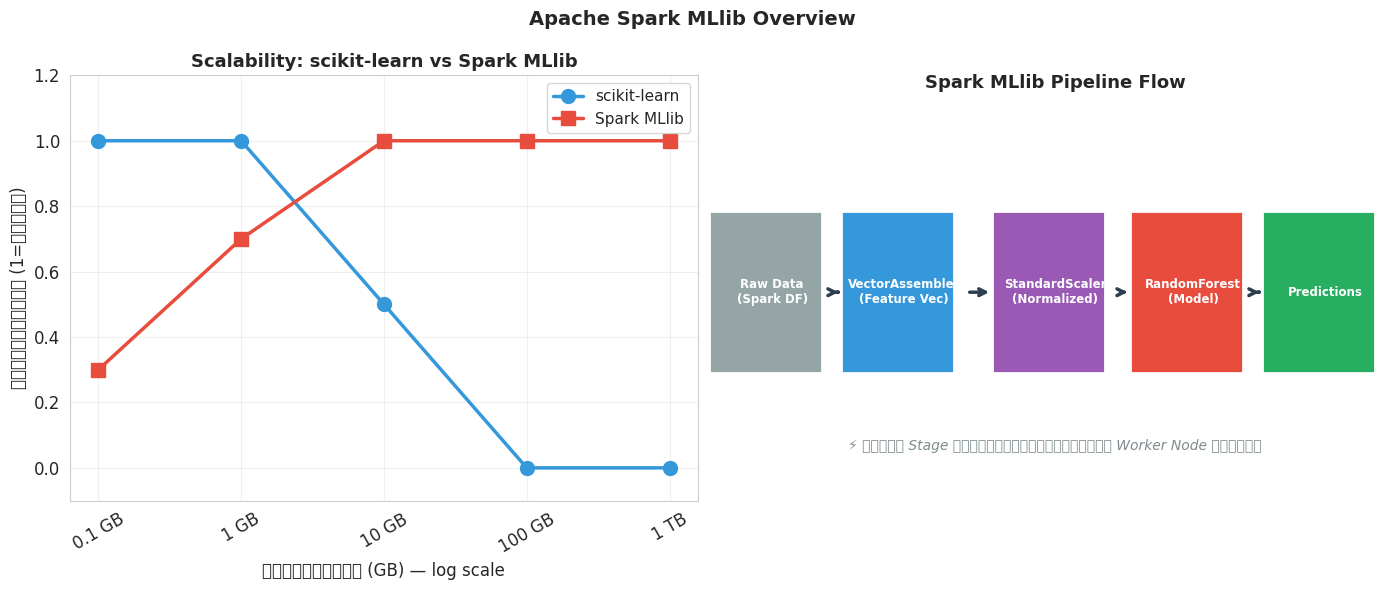

In [28]:
# แสดงภาพเปรียบเทียบ scikit-learn vs Spark MLlib
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# กราฟ 1: Scalability Comparison
data_sizes_gb = [0.1, 1, 10, 100, 1000]
sklearn_feasible = [1, 1, 0.5, 0, 0]
spark_feasible   = [0.3, 0.7, 1, 1, 1]

axes[0].plot(data_sizes_gb, sklearn_feasible, 'o-',
             color='#3498DB', linewidth=2.5, markersize=10, label='scikit-learn')
axes[0].plot(data_sizes_gb, spark_feasible, 's-',
             color='#E74C3C', linewidth=2.5, markersize=10, label='Spark MLlib')
axes[0].set_xscale('log')
axes[0].set_xlabel('ขนาดข้อมูล (GB) — log scale', fontsize=12)
axes[0].set_ylabel('ความเหมาะสม (1=ดีมาก)', fontsize=12)
axes[0].set_title('Scalability: scikit-learn vs Spark MLlib', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 1.2)
axes[0].set_xticks(data_sizes_gb)
axes[0].set_xticklabels(['0.1 GB', '1 GB', '10 GB', '100 GB', '1 TB'], rotation=30)

# กราฟ 2: Spark MLlib Pipeline Flow
axes[1].axis('off')
stages = ['Raw Data\n(Spark DF)', 'VectorAssembler\n(Feature Vec)', 'StandardScaler\n(Normalized)', 'RandomForest\n(Model)', 'Predictions']
colors_flow = ['#95A5A6', '#3498DB', '#9B59B6', '#E74C3C', '#27AE60']
x_positions = [0.05, 0.26, 0.50, 0.72, 0.93]

for i, (stage, color, x) in enumerate(zip(stages, colors_flow, x_positions)):
    box = plt.Rectangle((x - 0.10, 0.30), 0.18, 0.38,
                         facecolor=color, edgecolor='white', linewidth=2,
                         transform=axes[1].transAxes, clip_on=False)
    axes[1].add_patch(box)
    axes[1].text(x, 0.49, stage, transform=axes[1].transAxes,
                ha='center', va='center', color='white',
                fontsize=8.5, fontweight='bold')
    if i < len(stages) - 1:
        axes[1].annotate('', xy=(x_positions[i+1] - 0.10, 0.49),
                        xytext=(x + 0.10, 0.49),
                        xycoords='axes fraction', textcoords='axes fraction',
                        arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2.5))

axes[1].set_title('Spark MLlib Pipeline Flow', fontsize=13, fontweight='bold', y=0.95)
axes[1].text(0.5, 0.12, '⚡ แต่ละ Stage กระจายการคำนวณไปยัง Worker Node ทุกตัว',
             transform=axes[1].transAxes, ha='center', fontsize=10,
             color='#7F8C8D', style='italic')

plt.suptitle('Apache Spark MLlib Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ส่วนที่ 9: 🌐 Ray — Distributed ML Framework รุ่นใหม่

**Ray** คือ framework สำหรับ Distributed Computing ที่ออกแบบมาเพื่อ **Scale Python applications** รวมถึง ML ไปสู่ Cluster  
พัฒนาโดย UC Berkeley RISELab และปัจจุบันดูแลโดย Anyscale

### 🧩 Ecosystem ของ Ray
```
Ray Core (ระบบ task scheduling แบบ distributed)
├── Ray Train    → Distributed Model Training
│   └── รองรับ PyTorch, TensorFlow, XGBoost, scikit-learn
├── Ray Tune     → Hyperparameter Optimization (HPO)
│   └── รองรับ Algorithm: Optuna, HyperOpt, ASHA, PopulationBased
├── Ray Serve    → Model Serving / Deployment
├── Ray Data     → Distributed Data Processing
└── RLlib        → Reinforcement Learning
```

### 🆚 Ray vs Spark MLlib
| ด้าน | Spark MLlib | Ray |
|------|-------------|-----|
| **จุดแข็ง** | SQL + ML รวมกัน | Python-native, รองรับ DL |
| **Deep Learning** | จำกัด | รองรับ GPU, PyTorch |
| **Hyperparameter Tuning** | CrossValidator พื้นฐาน | Ray Tune (state-of-art) |
| **Ecosystem** | Spark ecosystem | Python ML ecosystem |
| **Use Case หลัก** | Big Data + ML pipeline | Research → Production |
| **Overhead** | สูง (JVM) | ต่ำกว่า (Python-native) |

### 🏗️ แนวคิด Ray Core: Task และ Actor
- **Ray Task** = ฟังก์ชันที่รันแบบ async บน Remote Worker
- **Ray Actor** = Object ที่มีสถานะ (stateful) กระจายบน Cluster

In [29]:
# ติดตั้ง Ray (รันครั้งแรกเท่านั้น)
# !pip install 'ray[train,tune]'

try:
    import ray
    from ray import tune
    RAY_AVAILABLE = True
    print('✅ Ray พร้อมใช้งาน!')
    print(f'   Ray version: {ray.__version__}')
except ImportError:
    RAY_AVAILABLE = False
    print('⚠️  Ray ไม่ได้ติดตั้ง — รันใน simulation mode')
    print('   ติดตั้งด้วย: pip install ray[train,tune]')

⚠️  Ray ไม่ได้ติดตั้ง — รันใน simulation mode
   ติดตั้งด้วย: pip install ray[train,tune]


In [30]:
# ===== ตัวอย่าง Ray Core: Parallel Task Execution =====
if RAY_AVAILABLE:
    import ray
    if not ray.is_initialized():
        ray.init(ignore_reinit_error=True, num_cpus=4)

    @ray.remote
    def train_model_remote(depth, X_train_np, y_train_np, X_test_np, y_test_np):
        """ฟังก์ชันที่รันบน Remote Worker"""
        import numpy as np
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.metrics import accuracy_score
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        model.fit(X_train_np, y_train_np)
        acc = accuracy_score(y_test_np, model.predict(X_test_np))
        return {'depth': depth, 'accuracy': acc}

    X_tr_np = X_train.values
    y_tr_np = y_train.values
    X_te_np = X_test.values
    y_te_np = y_test.values

    import time
    print('🚀 รัน Parallel Training ด้วย Ray (8 โมเดลพร้อมกัน)...')
    t0 = time.time()
    futures = [train_model_remote.remote(d, X_tr_np, y_tr_np, X_te_np, y_te_np)
               for d in range(1, 9)]
    results_ray = ray.get(futures)  # รอผลทั้งหมด
    elapsed_ray = time.time() - t0

    print(f'✅ เสร็จสิ้นใน {elapsed_ray:.2f} วินาที')
    results_ray_df = pd.DataFrame(results_ray)
    display(results_ray_df.sort_values('depth'))

else:
    # แสดง concept + simulation
    print('💡 Ray ทำงานอย่างไร: Parallel Task Execution\n')
    print('@ray.remote  ← decorator ทำให้ฟังก์ชันรันบน Remote Worker')
    print('def train_model(depth): ...')
    print()
    print('# ยิง 8 task พร้อมกัน (ไม่รอทีละตัว)')
    print('futures = [train_model.remote(d) for d in range(1, 9)]')
    print()
    print('# รอผลทั้งหมด')
    print('results = ray.get(futures)\n')

    # Sequential simulation
    import time
    sim_results = []
    t0 = time.time()
    for d in range(1, 9):
        m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
        acc = accuracy_score(y_test, m.predict(X_test))
        sim_results.append({'depth': d, 'accuracy': acc})
    elapsed_seq = time.time() - t0
    results_ray_df = pd.DataFrame(sim_results)
    print(f'📋 ผลลัพธ์ (sequential simulation ใช้เวลา {elapsed_seq*1000:.1f} ms):')
    display(results_ray_df)

💡 Ray ทำงานอย่างไร: Parallel Task Execution

@ray.remote  ← decorator ทำให้ฟังก์ชันรันบน Remote Worker
def train_model(depth): ...

# ยิง 8 task พร้อมกัน (ไม่รอทีละตัว)
futures = [train_model.remote(d) for d in range(1, 9)]

# รอผลทั้งหมด
results = ray.get(futures)

📋 ผลลัพธ์ (sequential simulation ใช้เวลา 39.5 ms):


,depth,accuracy
0,1,0.75
1,2,0.75
2,3,0.69
3,4,0.68
4,5,0.66
5,6,0.68
6,7,0.64
7,8,0.65


In [31]:
# ===== ตัวอย่าง Ray Tune: Hyperparameter Optimization =====
if RAY_AVAILABLE:
    from ray import tune

    X_tr_np = X_train.values
    y_tr_np = y_train.values
    X_te_np = X_test.values
    y_te_np = y_test.values

    def train_tune(config):
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import accuracy_score
        model = RandomForestClassifier(
            n_estimators=config['n_estimators'],
            max_depth=config['max_depth'],
            min_samples_split=config['min_samples_split'],
            random_state=42
        )
        model.fit(X_tr_np, y_tr_np)
        acc = accuracy_score(y_te_np, model.predict(X_te_np))
        tune.report({'accuracy': acc})

    search_space = {
        'n_estimators'     : tune.randint(50, 300),
        'max_depth'        : tune.randint(2, 12),
        'min_samples_split': tune.randint(2, 20),
    }

    print('🔍 เริ่ม Ray Tune: Hyperparameter Search (20 trials)...')
    tuner = tune.Tuner(
        train_tune,
        param_space=search_space,
        tune_config=tune.TuneConfig(
            num_samples=20,
            metric='accuracy',
            mode='max'
        ),
    )
    results_tune = tuner.fit()
    best_result = results_tune.get_best_result()

    print(f'\n🏆 Best Hyperparameters:')
    for k, v in best_result.config.items():
        print(f'   {k}: {v}')
    print(f'   Best Accuracy: {best_result.metrics["accuracy"]:.4f}')

else:
    print('📋 Ray Tune: Hyperparameter Optimization Template\n')
    print('Search Space ที่ Ray Tune จะค้นหา:')
    search_space_demo = {
        'n_estimators'     : 'tune.randint(50, 300)',
        'max_depth'        : 'tune.randint(2, 12)',
        'min_samples_split': 'tune.randint(2, 20)',
    }
    for k, v in search_space_demo.items():
        print(f'  {k:25s} = {v}')

    print('\n💡 ข้อดีของ Ray Tune:')
    print('  - ค้นหา hyperparameter แบบขนาน (parallel)')
    print('  - รองรับ algorithm อัจฉริยะ: ASHA, PBT, Optuna')
    print('  - Early Stopping: หยุด trial ที่แย่เร็ว ประหยัดทรัพยากร')
    print('  - Dashboard แสดงผล real-time')

📋 Ray Tune: Hyperparameter Optimization Template

Search Space ที่ Ray Tune จะค้นหา:
  n_estimators              = tune.randint(50, 300)
  max_depth                 = tune.randint(2, 12)
  min_samples_split         = tune.randint(2, 20)

💡 ข้อดีของ Ray Tune:
  - ค้นหา hyperparameter แบบขนาน (parallel)
  - รองรับ algorithm อัจฉริยะ: ASHA, PBT, Optuna
  - Early Stopping: หยุด trial ที่แย่เร็ว ประหยัดทรัพยากร
  - Dashboard แสดงผล real-time


In [32]:
# ===== Ray Train: Distributed Training Template =====
print('📋 Ray Train: Distributed Training Concept\n')

ray_train_template = '''
import ray.train as train
from ray.train.sklearn import SklearnTrainer
from sklearn.ensemble import RandomForestClassifier

# กำหนด Trainer
trainer = SklearnTrainer(
    estimator=RandomForestClassifier(n_estimators=100, max_depth=6),
    label_column="high_risk",
    scoring=["accuracy", "roc_auc"],
    datasets={"train": train_dataset, "valid": valid_dataset},
    run_config=train.RunConfig(
        name="crime_rf_experiment",
        storage_path="/tmp/ray_results",
    ),
)

# รัน Training (กระจายไปยัง Workers อัตโนมัติ)
result = trainer.fit()
print(f"Best checkpoint: {result.checkpoint}")
print(f"Metrics: {result.metrics}")
'''
print(ray_train_template)

print('\n💡 Ray Train ทำให้สามารถ:')
print('  ✅ กระจาย Training ไปยังหลาย GPU/CPU บน Cluster')
print('  ✅ บันทึก Checkpoint อัตโนมัติ')
print('  ✅ ใช้ร่วมกับ Ray Tune สำหรับ HPO + Distributed Training')
print('  ✅ รองรับ PyTorch, TensorFlow, XGBoost, scikit-learn')

📋 Ray Train: Distributed Training Concept


import ray.train as train
from ray.train.sklearn import SklearnTrainer
from sklearn.ensemble import RandomForestClassifier

# กำหนด Trainer
trainer = SklearnTrainer(
    estimator=RandomForestClassifier(n_estimators=100, max_depth=6),
    label_column="high_risk",
    scoring=["accuracy", "roc_auc"],
    datasets={"train": train_dataset, "valid": valid_dataset},
    run_config=train.RunConfig(
        name="crime_rf_experiment",
        storage_path="/tmp/ray_results",
    ),
)

# รัน Training (กระจายไปยัง Workers อัตโนมัติ)
result = trainer.fit()
print(f"Best checkpoint: {result.checkpoint}")
print(f"Metrics: {result.metrics}")


💡 Ray Train ทำให้สามารถ:
  ✅ กระจาย Training ไปยังหลาย GPU/CPU บน Cluster
  ✅ บันทึก Checkpoint อัตโนมัติ
  ✅ ใช้ร่วมกับ Ray Tune สำหรับ HPO + Distributed Training
  ✅ รองรับ PyTorch, TensorFlow, XGBoost, scikit-learn


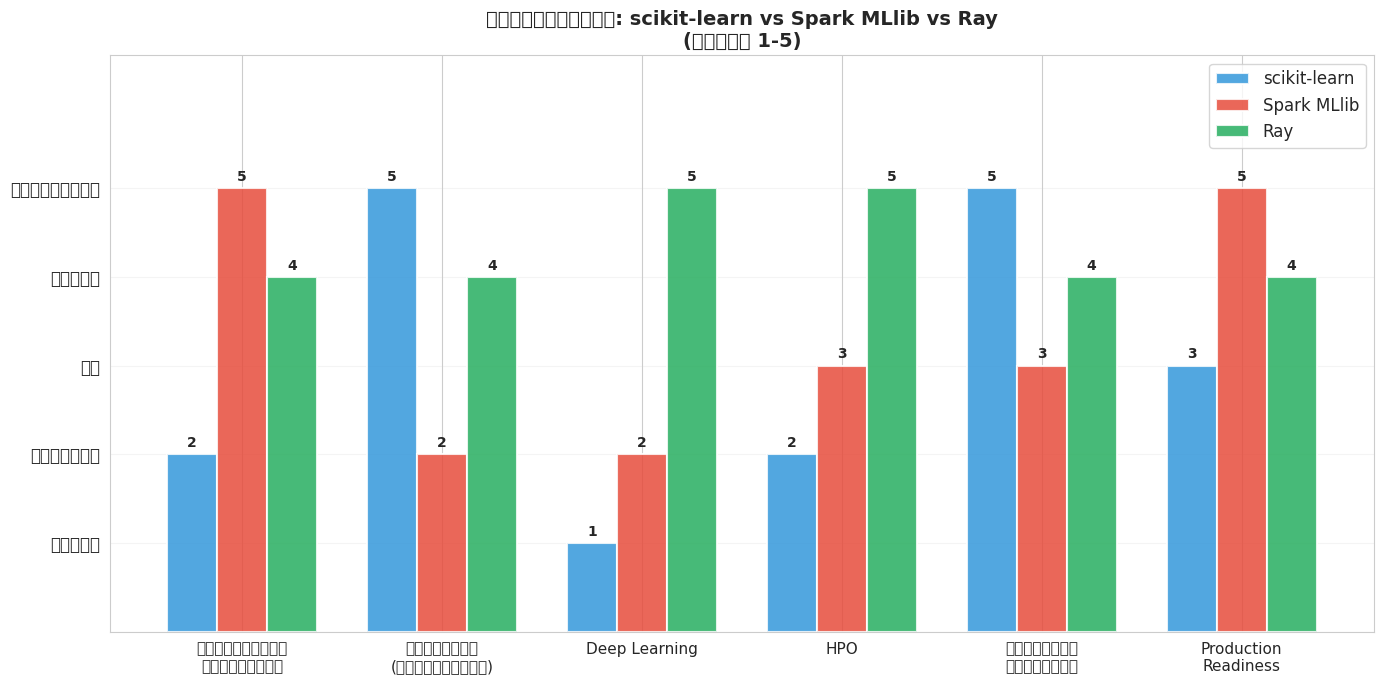


📌 สรุปแนวทางเลือกใช้:
  scikit-learn : ข้อมูล < 10GB | Prototype | Classic ML
  Spark MLlib  : ข้อมูล > 10GB | SQL+ML Pipeline | Batch
  Ray          : Deep Learning | Advanced HPO | Multi-framework


In [33]:
# ===== เปรียบเทียบ 3 Framework: scikit-learn vs Spark MLlib vs Ray =====
fig, ax = plt.subplots(figsize=(14, 7))

categories = ['ขนาดข้อมูล\nที่รองรับ', 'ความเร็ว\n(ข้อมูลเล็ก)', 'Deep Learning', 'HPO', 'ความง่าย\nในการใช้', 'Production\nReadiness']
sklearn_scores = [2, 5, 1, 2, 5, 3]
spark_scores   = [5, 2, 2, 3, 3, 5]
ray_scores     = [4, 4, 5, 5, 4, 4]

x = np.arange(len(categories))
width = 0.25

bars1 = ax.bar(x - width, sklearn_scores, width, label='scikit-learn',
               color='#3498DB', alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x,          spark_scores,   width, label='Spark MLlib',
               color='#E74C3C', alpha=0.85, edgecolor='white', linewidth=1.5)
bars3 = ax.bar(x + width,  ray_scores,     width, label='Ray',
               color='#27AE60', alpha=0.85, edgecolor='white', linewidth=1.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.05,
                str(h), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_yticks(range(6))
ax.set_yticklabels(['', 'พอใช้', 'ปานกลาง', 'ดี', 'ดีมาก', 'ยอดเยี่ยม'])
ax.set_title('เปรียบเทียบ: scikit-learn vs Spark MLlib vs Ray\n(คะแนน 1-5)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.set_ylim(0, 6.5)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

print('\n📌 สรุปแนวทางเลือกใช้:')
print('  scikit-learn : ข้อมูล < 10GB | Prototype | Classic ML')
print('  Spark MLlib  : ข้อมูล > 10GB | SQL+ML Pipeline | Batch')
print('  Ray          : Deep Learning | Advanced HPO | Multi-framework')

---
## 📚 สรุปความรู้ประจำสัปดาห์

| แนวคิด | สาระสำคัญ |
|--------|----------|
| **Machine Learning** | คอมพิวเตอร์เรียนรู้จากข้อมูลแทนการโปรแกรมกฎโดยตรง |
| **Supervised Learning** | เรียนรู้จากข้อมูลที่มี Label → Classification / Regression |
| **Train-Test Split** | แบ่งข้อมูลเพื่อฝึกโมเดลและทดสอบบนข้อมูลใหม่ |
| **Overfitting** | โมเดลท่องจำ Training แต่ทำได้แย่กับข้อมูลใหม่ |
| **Accuracy / F1** | Metrics พื้นฐานสำหรับ Classification |
| **R² / RMSE** | Metrics พื้นฐานสำหรับ Regression |
| **Spark MLlib** | ML บน Distributed Cluster — รองรับข้อมูล TB-PB |
| **MLlib Pipeline** | เชื่อม Transformer + Estimator เข้า Stage อัตโนมัติ |
| **Ray** | Python-native Distributed ML — รองรับ DL + HPO |
| **Ray Tune** | Hyperparameter Optimization แบบขนาน + Smart Search |
| **Ray Train** | Distributed Training รองรับ PyTorch, TF, XGBoost |

### 🗺️ แผนที่การเลือกใช้ Framework
```
ข้อมูลขนาดเล็ก (< 10 GB) + Classic ML
  └── scikit-learn ✅

ข้อมูลขนาดใหญ่ (> 10 GB) + SQL/Batch pipeline
  └── Spark MLlib ✅

Deep Learning + Advanced HPO + Multi-GPU
  └── Ray (Train + Tune) ✅

ข้อมูลใหญ่ + DL (Production-grade)
  └── Spark + Ray (ใช้ร่วมกัน) ✅
```

---

## 🔗 แหล่งเรียนรู้เพิ่มเติม
- [scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)
- [Spark MLlib Guide](https://spark.apache.org/docs/latest/ml-guide.html)
- [Ray Documentation](https://docs.ray.io/en/latest/)
- [Ray Tune — Hyperparameter Tuning](https://docs.ray.io/en/latest/tune/index.html)
- [Ray Train — Distributed Training](https://docs.ray.io/en/latest/train/train.html)
- [Google ML Crash Course](https://developers.google.com/machine-learning/crash-course)
- Géron, A. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*

---
*📖 สัปดาห์หน้า: การประกันคุณภาพข้อมูล (Data Quality Assurance)*